# 1. Modeling Naive Bayes

In [9]:
!pip install scikit-learn pandas seaborn matplotlib -q

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
# --- Mempersiapkan Data ---
try:
    # Muat data fitur (X) dari TF-IDF
    X = pd.read_csv('tfidf_features.csv')
    
    # Muat data untuk mendapatkan label sentimen (y)
    df_labels = pd.read_csv('../Week2/df_rosaliarev_preprocessed.csv')
    
    # Buat kolom sentimen jika belum ada
    if 'sentiment' not in df_labels.columns:
        def get_sentiment(score):
            if score >= 4: return 'Positif'
            elif score <= 2: return 'Negatif'
            else: return 'Netral'
        df_labels['sentiment'] = df_labels['score'].apply(get_sentiment)

    y = df_labels['sentiment']
    
    # Menyelaraskan X dan y
    valid_indices = y.notna()
    y = y[valid_indices]
    X = X[valid_indices]

    print("Data fitur (TF-IDF) dan target (y) berhasil dimuat.")
    print(f"Jumlah data: {len(y)} ulasan.")

except FileNotFoundError as e:
    print(f"Error: Pastikan file 'tfidf_features.csv' dan 'df_rosaliarev_preprocessed.csv' ada. {e}")
    exit()

Data fitur (TF-IDF) dan target (y) berhasil dimuat.
Jumlah data: 3973 ulasan.


In [12]:
# --- Membagi Data ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)
print(f"Data dibagi menjadi {len(y_train)} data latih dan {len(y_test)} data uji.")

Data dibagi menjadi 3178 data latih dan 795 data uji.


In [13]:
# --- Melatih Model Naive Bayes ---
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
print("\nModel Naive Bayes berhasil dilatih.")


Model Naive Bayes berhasil dilatih.



--- Hasil Evaluasi: Naive Bayes ---
Akurasi Model: 81.13%

Laporan Klasifikasi:
              precision    recall  f1-score   support

     Negatif       0.77      0.90      0.83       340
      Netral       0.00      0.00      0.00        69
     Positif       0.86      0.88      0.87       386

    accuracy                           0.81       795
   macro avg       0.54      0.59      0.57       795
weighted avg       0.74      0.81      0.78       795



C:\Users\Wede\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Wede\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Wede\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

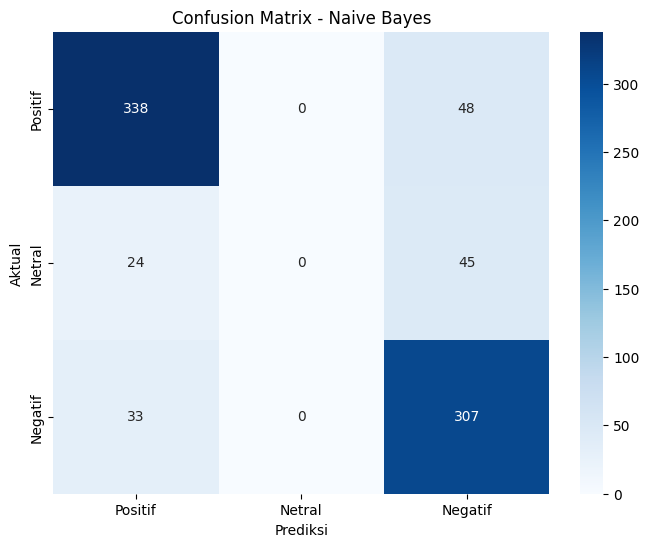

In [14]:
# --- Evaluasi Model Naive Bayes ---
y_pred_nb = nb_model.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print(f"\n--- Hasil Evaluasi: Naive Bayes ---")
print(f"Akurasi Model: {accuracy_nb:.2%}")
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred_nb))

# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=['Positif', 'Netral', 'Negatif'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Positif', 'Netral', 'Negatif'], 
            yticklabels=['Positif', 'Netral', 'Negatif'])
plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

# 2. Modeling Logistic Regression

In [15]:
# --- Latih Model Logistic Regression ---
logreg_model = LogisticRegression(
    class_weight='balanced', 
    random_state=42,
    max_iter=1000 
)
logreg_model.fit(X_train, y_train)
print("🧠 Model Logistic Regression berhasil dilatih.")

🧠 Model Logistic Regression berhasil dilatih.



--- Hasil Evaluasi: Logistic Regression ---
Akurasi Model: 72.96%

Laporan Klasifikasi:
              precision    recall  f1-score   support

     Negatif       0.83      0.69      0.75       340
      Netral       0.20      0.45      0.28        69
     Positif       0.88      0.82      0.85       386

    accuracy                           0.73       795
   macro avg       0.64      0.65      0.63       795
weighted avg       0.80      0.73      0.76       795



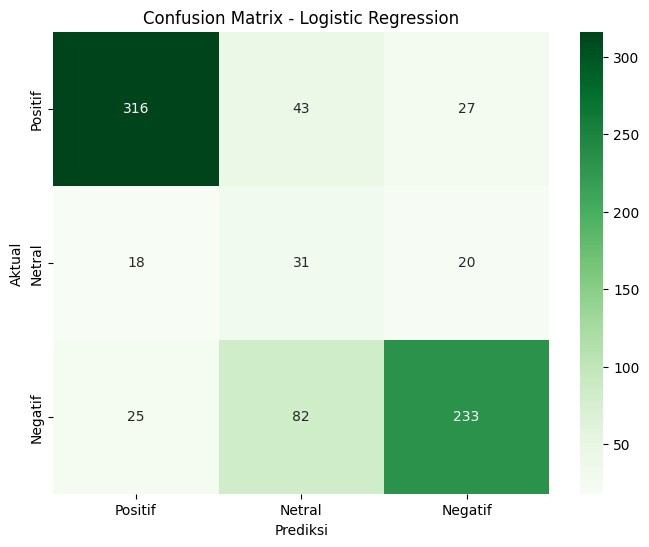

In [16]:
# --- Evaluasi Model Logistic Regression ---
y_pred_logreg = logreg_model.predict(X_test)
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)

print(f"\n--- Hasil Evaluasi: Logistic Regression ---")
print(f"Akurasi Model: {accuracy_logreg:.2%}")
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred_logreg))

# Confusion Matrix Logistic Regression
cm_logreg = confusion_matrix(y_test, y_pred_logreg, labels=['Positif', 'Netral', 'Negatif'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Positif', 'Netral', 'Negatif'], 
            yticklabels=['Positif', 'Netral', 'Negatif'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()